Step Size (h)   | Max |Eigenvalue|   | Stability Status
-------------------------------------------------------
0.01            | 1.0000             | Solution may not be Entirely Stable ;)
0.05            | 1.0012             | Solution may not be Entirely Stable ;)
0.10            | 1.0050             | Solution may not be Entirely Stable ;)
0.20            | 1.0198             | Solution may not be Entirely Stable ;)
0.50            | 1.1180             | Solution may not be Entirely Stable ;)


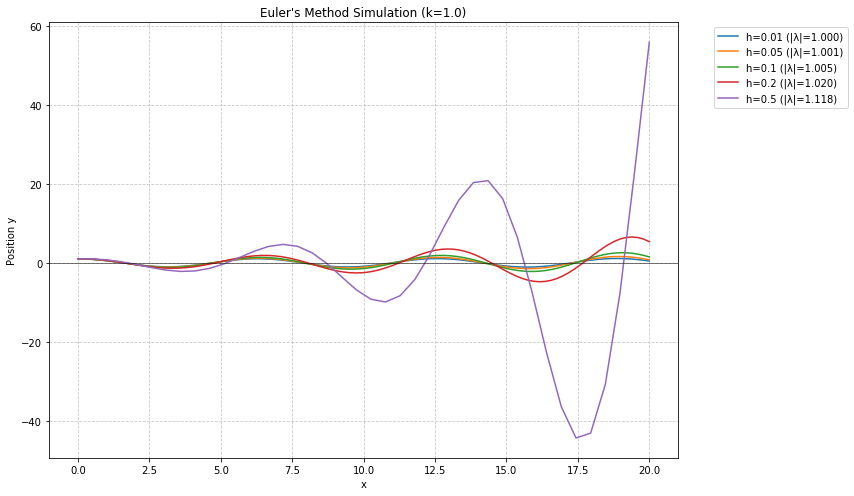

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_euler_stability(k, h_values, x_end=20):
    y0, v0 = 1.0, 0.0
    plt.figure(figsize=(12, 7))
    
    print(f"{'Step Size (h)':<15} | {'Max |Eigenvalue|':<18} | {'Stability Status'}")
    print("-" * 55)

    for h in h_values:
        
        A = np.array([[1, h], 
                      [-k*h, 1]])

        eigenvalues = np.linalg.eigvals(A)
        max_eig_mag = np.max(np.abs(eigenvalues))

       
        status = "Solution is Stable" if max_eig_mag <= 1 else "Solution may not be Entirely Stable ;)"
        print(f"{h:<15.2f} | {max_eig_mag:<18.4f} | {status}")

        
        steps = int(x_end / h)
        x_plot = np.linspace(0, x_end, steps)
        y_sim = np.zeros(steps)
        v_sim = np.zeros(steps)
        
        y_sim[0], v_sim[0] = y0, v0
        
        state = np.array([y0, v0])
        for i in range(1, steps):
            state = A @ state 
            y_sim[i] = state[0]
            
        plt.plot(x_plot, y_sim, label=f'h={h} (|λ|={max_eig_mag:.3f})')

    plt.axhline(0, color='black', lw=1, alpha=0.5)
    plt.title(f"Euler's Method Simulation (k={k})")
    plt.xlabel("x")
    plt.ylabel("Position y")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


k_constant = 1.0
test_h = [0.01, 0.05, 0.1, 0.2, 0.5]
analyze_euler_stability(k_constant, test_h)